In [1]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from python.animation import *
from python.postprocess import *
sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


## Load data for correction

In [2]:
labels_to_correct_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/simplemax-tracking/c3_simplemax_tracking.slp'
labels_to_correct = sleap.load_file(labels_to_correct_path)
print(labels_to_correct)
all_tracked_points = get_all_tracked_points(labels_to_correct, reorder=True)
id_mapping = get_id_mapping_array(all_tracked_points)

Labels(labeled_frames=828, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (827, 17, 2)
Missing point count: 105
reorder_idx.shape: (17,)


## Load corrected data (ground truth)

In [3]:
corrected_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/simplemax-tracking/c3_simplemax_tracking_corrected.slp'
corrected_labels = sleap.load_file(corrected_labels_path)
print(corrected_labels)
all_tracked_points_corrected = get_all_tracked_points(corrected_labels, reorder=True)
id_mapping_corrected = get_id_mapping_array(all_tracked_points_corrected)

Labels(labeled_frames=828, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (827, 17, 2)
Missing point count: 105
reorder_idx.shape: (17,)


## Candidates

### c1: center angle-based polygon construction

Algorithm:
1. for each frame:
    1. calculate the center position by averaging all point coordinates 
    2. for each point:
        1. calculate the angle between this point and the center position
    3. find the polygon order by sorting the angles 
    4. shift/rotate the polygon order to maximally align with the order from the previous frame 
    5. for each point:
        1. if the order from the latter from is inconsistent with the previous frame, correct it by assigning the same identity from the previous frame 

Notes:
- this is extremely sensitive to mispredicted points -> use a hard threshold to remove points with predicted score < 0.4?
- add old/new labels when rendering animations

In [4]:
(labels_to_correct.labeled_frames[1].instances[0])

PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4, shape=(828, 170, 174, 1), backend=MediaVideo), frame_idx=1, points=[tb1_node: (106.4, 28.5, 1.00)], score=0.91, track=Track(spawned_on=0, name='track_0'), tracking_score=-0.02)

In [5]:
def find_best_roll(curr_frame_indices: np.ndarray, prev_frame_indices: np.ndarray) -> int:
    """
    Find the optimal roll shift that maximizes alignment between two index arrays
    
    Args:
        curr_frame_indices: array of current frame indices
        prev_frame_indices: array of previous frame indices
        
    Returns:
        best_shift: integer shift that maximizes alignment
    """
    if np.array_equal(curr_frame_indices, prev_frame_indices):
        return 0
    n = len(curr_frame_indices)
    max_matches = 0
    best_shift = 0

    for shift in range(n):
        rolled = np.roll(curr_frame_indices, shift)
        matches = np.sum(rolled == prev_frame_indices)
        if matches > max_matches:
            max_matches = matches
            best_shift = shift      
    return best_shift

In [6]:
def c1_correction(all_tracked_points, id_mapping):
    id_mapping = id_mapping.copy()
    frame_cnt = all_tracked_points.shape[0]
    for frame_idx in range(1, frame_cnt):
        center_pos = np.mean(all_tracked_points[frame_idx], axis=0)
        coord_diff = all_tracked_points[frame_idx] - center_pos
        angles = np.arctan2(coord_diff[:, 1], coord_diff[:, 0])
        sorted_indices = np.argsort(angles)
        prev_frame_indices = id_mapping[frame_idx-1]
        best_shift = find_best_roll(sorted_indices, prev_frame_indices)
        shifted_indices = np.roll(sorted_indices, best_shift)
        correction_cnt = np.sum(id_mapping[frame_idx] != id_mapping[frame_idx-1])
        if frame_idx < 10 or best_shift != 0 or correction_cnt > 0:
            print(f"============================== Frame {frame_idx} ==============================")
            print(f"Center position:    {center_pos}")
            print(f"Sorted indices:     {sorted_indices}")
            print(f"Prev frame indices: {prev_frame_indices}")
            print(f"Best shift: {best_shift}")
            print(f"Correction count: {correction_cnt}")
            if best_shift != 0:
                print(f'Shifted indices:    {shifted_indices}')
        id_mapping[frame_idx] = id_mapping[frame_idx-1][shifted_indices]
    return id_mapping

def get_corrected_coords(all_tracked_points, id_mapping):
    corrected_coords = all_tracked_points.copy()
    for frame_idx in range(1, all_tracked_points.shape[0]):
        corrected_coords[frame_idx] = all_tracked_points[frame_idx][id_mapping[frame_idx]]
    return corrected_coords

In [7]:
c1_points = get_all_tracked_points(labels_to_correct, reorder=True, min_score=0.4)
c1_corrected_mapping = c1_correction(c1_points, id_mapping)
c1_corrected_coords = get_corrected_coords(c1_points, c1_corrected_mapping)

all_tracked_points shape: (827, 17, 2)
Missing point count: 116
reorder_idx.shape: (17,)
============================== Frame 1 ==============================
Center position:    [87.43061739 82.43363134]
Sorted indices:     [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Prev frame indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Best shift: 0
Correction count: 0
============================== Frame 2 ==============================
Center position:    [87.3420372 82.4264109]
Sorted indices:     [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Prev frame indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Best shift: 0
Correction count: 0
============================== Frame 3 ==============================
Center position:    [87.3240693  82.42602449]
Sorted indices:     [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Prev frame indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Best shift: 0
Correction count: 0
=========================

In [8]:
c1_corrected_coords.shape

(827, 17, 2)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/c3_c1_corrected.mp4
Animation saved to /home/mingxiao/Desktop/animation/c3_c1_corrected.mp4


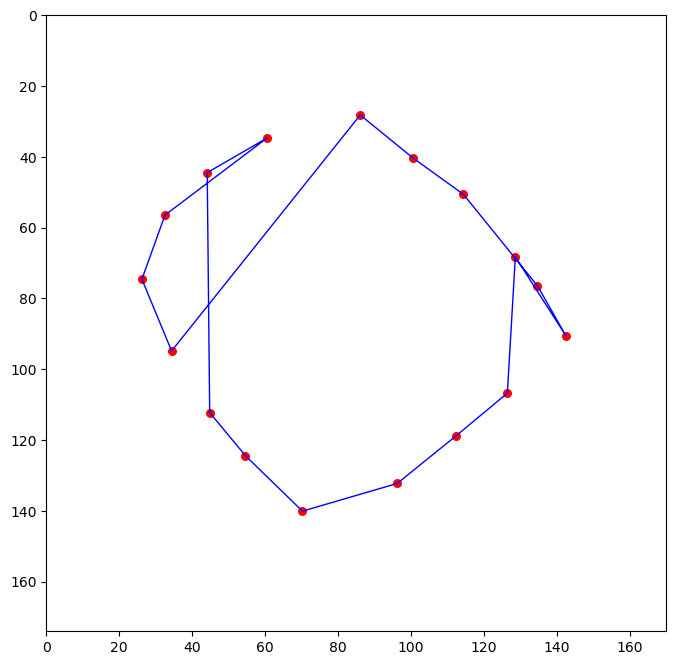

In [10]:
corrected_animation_path = '/home/mingxiao/Desktop/animation/c3_c1_corrected.mp4'
frame_cnt, x, y = labels_to_correct.video.shape[:3]
get_animation_from_tracked_points(c1_corrected_coords, x, y, output_path=corrected_animation_path)

In [12]:
c1_corrected_coords.size

28118

In [9]:
np.sum(c1_corrected_coords != all_tracked_points_corrected) / 2 

2468.0

In [44]:
c1_corrected_mapping

array([[ 0,  1,  2, ..., 14, 15, 16],
       [ 0,  1,  2, ..., 14, 15, 16],
       [ 0,  1,  2, ..., 14, 15, 16],
       ...,
       [ 9,  4, 16, ..., 14, 15,  1],
       [ 1,  4, 16, ..., 14, 15,  9],
       [ 9,  4, 16, ..., 14, 15,  1]])

In [43]:
print(id_mapping_corrected)

[[ 0  1  2 ... 14 15 16]
 [ 0  1  2 ... 14 15 16]
 [ 0  1  2 ... 14 15 16]
 ...
 [ 0  1  2 ... 14 15 16]
 [ 0  1  2 ... 14 15 16]
 [ 0  1  2 ... 14 15 16]]


Total number of differences: 4163

Differences per point:
Point 0: 311 differences
Point 1: 89 differences
Point 2: 88 differences
Point 3: 630 differences
Point 4: 628 differences
Point 5: 34 differences
Point 6: 596 differences
Point 7: 526 differences
Point 8: 347 differences
Point 9: 604 differences
Point 10: 0 differences
Point 11: 0 differences
Point 12: 0 differences
Point 13: 0 differences
Point 14: 0 differences
Point 15: 0 differences
Point 16: 310 differences


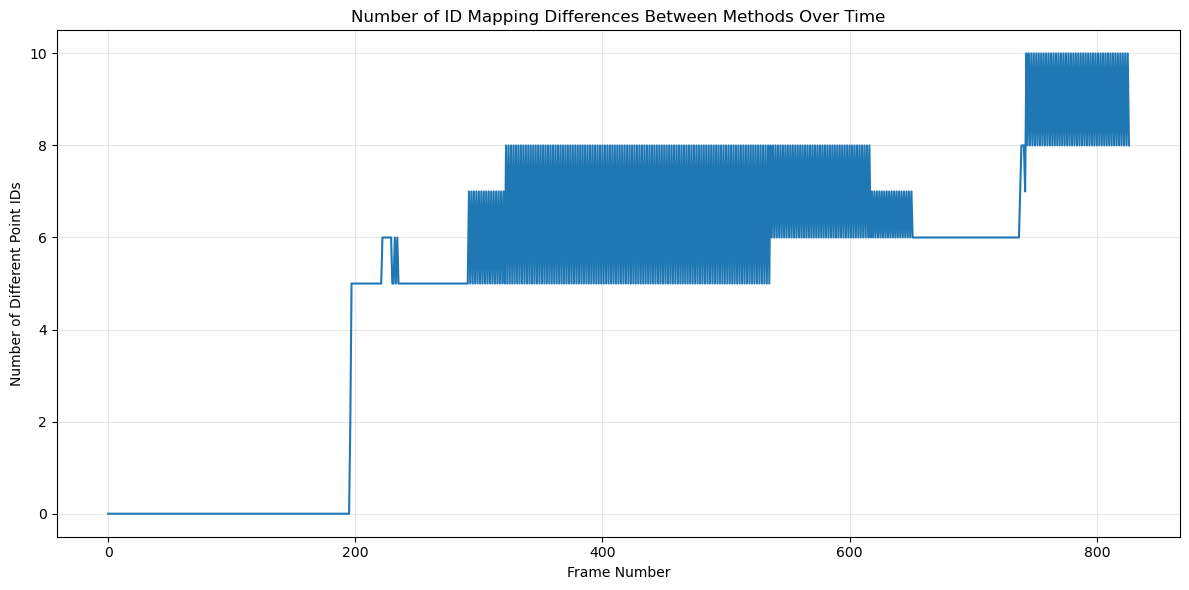

In [34]:
# Count total differences
differences = np.sum(c1_corrected_mapping != id_mapping_corrected)
print(f"Total number of differences: {differences}")

# Count differences per point
differences_per_point = np.sum(c1_corrected_mapping != id_mapping_corrected, axis=0)
print("\nDifferences per point:")
for point_idx, diff_count in enumerate(differences_per_point):
    print(f"Point {point_idx}: {diff_count} differences")

# Count differences per frame
differences_per_frame = np.sum(c1_corrected_mapping != id_mapping_corrected, axis=1)

# Plot differences over time
plt.figure(figsize=(12, 6))
plt.plot(differences_per_frame)
plt.xlabel('Frame Number')
plt.ylabel('Number of Different Point IDs')
plt.title('Number of ID Mapping Differences Between Methods Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### c2: shortest path-based polygon construction

### c3: displacement/nn distance-based swap detection

### c4: radial/tangential velocity-based swap detection